In [ ]:
#pip install --upgrade pandas

In [83]:
# ── MBA notebook — setup & load clustering handoff ─────────────────────────
import pickle, warnings, re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

with open('clustering_handoff.pkl', 'rb') as _f:
    _h = pickle.load(_f)

df_units          = _h['df_units']
df_used_market    = _h['df_used_market']
name_map          = _h['name_map']
segmentation_data = _h['segmentation_data']
scaled_features   = _h['scaled_features']
scaler            = _h['scaler']

print('Clustering handoff loaded.')
print(f'  df_units          {df_units.shape}')
print(f'  df_used_market    {df_used_market.shape}')
print(f'  segmentation_data {segmentation_data.shape}')
print(f'  name_map keys     {len(name_map)}')


Clustering handoff loaded.
  df_units          (8599, 38)
  df_used_market    (10239, 37)
  segmentation_data (1586, 6)
  name_map keys     4234


In [84]:
# ── Enrich UNKNOWN MARCA / MODELO from DESCRIPTION_MERGED ────────────────────
# Uses make-model-cptrucks.xlsx as a reference dictionary.
# Two-pass approach:
#   1. Dictionary lookup  — exact model names from the Excel
#   2. Regex extraction   — model codes embedded in serial numbers / free text
import re
import pandas as pd

ref = pd.read_excel('make-model-cptrucks.xlsx')

# Non-makes and non-informative model strings to skip
_JUNK_MAKES  = {'BUCKET', 'CONTAINER', 'SPARE', 'SKID'}
_JUNK_MODELS = {'HAMMER', 'SPARE', 'PARTS', 'BLAUW', 'CONE', 'HOSE', 'III', 'NAN', 'NONE', ''}

# Build {UPPER_MAKE: {canonical, models}} from the Excel
_make_models = {}
for _, row in ref.iterrows():
    make  = str(row['make']).strip()
    model = str(row['model']).strip() if pd.notna(row['model']) else ''
    key   = make.upper()
    if key in _JUNK_MAKES:
        continue
    if key not in _make_models:
        _make_models[key] = {'canonical': make, 'models': set()}
    if model.upper() not in _JUNK_MODELS:
        _make_models[key]['models'].add(model)

# Longest make names first (prevents 'SYMONS' matching before 'SYMONS/METSO')
_sorted_makes = sorted(_make_models.keys(), key=len, reverse=True)

# Regex patterns to extract model codes from serial numbers / free text
_MODEL_REGEX = {
    'CATERPILLAR': [
        r'\bCAT0?([A-Z]{0,2}[0-9]{2,4}[A-Z]{0,2})\b',  # 962H, M322C, 262C, 329DL
        r'\b(IT[0-9]{2}[A-Z]?)\b',                       # IT14G
        r'\b(140[A-Z][0-9]?)\b',                         # 140M2, 140H
    ],
    'VOLVO': [
        r'\b([ELF][0-9]{2,3}[A-Z]{0,2})\b',             # L120C, L180, EW170, L90C
    ],
    'GOMACO': [
        r'\b(GT[0-9]{4}|[0-9]{3,4})\b',                 # GT6300, 603
    ],
}

def _extract_model_regex(make_key, desc_up):
    for pat in _MODEL_REGEX.get(make_key, []):
        m = re.search(pat, desc_up)
        if m:
            return m.group(1)
    return None

def _enrich_row(marca, modelo, desc):
    """Return (enriched_marca, enriched_modelo). Only fills UNKNOWN slots."""
    marca_unk = str(marca).upper().strip() in ('UNKNOWN', '', 'NAN')
    model_unk = str(modelo).upper().strip() in ('UNKNOWN', '', 'NAN')
    if not marca_unk and not model_unk:
        return marca, modelo

    desc_up = str(desc).upper() if pd.notna(desc) else ''

    # Find make in description
    found_key = None
    for key in _sorted_makes:
        if re.search(r'\b' + re.escape(key) + r'\b', desc_up):
            found_key = key
            break
    # CAT appears inside serial numbers without a strict word boundary
    if found_key is None and re.search(r'\bCAT\b', desc_up):
        found_key = 'CATERPILLAR'

    if found_key is None:
        return marca, modelo

    new_marca  = _make_models[found_key]['canonical'] if marca_unk else marca
    new_modelo = modelo

    if model_unk:
        # Pass 1: exact dictionary match
        for model in _make_models[found_key]['models']:
            if re.search(r'\b' + re.escape(model.upper()) + r'\b', desc_up):
                new_modelo = model
                break
        # Pass 2: regex extraction from serial / free text
        if str(new_modelo).upper().strip() in ('UNKNOWN', '', 'NAN'):
            extracted = _extract_model_regex(found_key, desc_up)
            if extracted:
                new_modelo = extracted

    return new_marca, new_modelo

# Apply to df_units in-place
_unk_before_marca  = (df_units['MARCA'].str.upper().str.strip() == 'UNKNOWN').sum()
_unk_before_modelo = (df_units['MODELO'].str.upper().str.strip() == 'UNKNOWN').sum()

_enriched = df_units.apply(
    lambda r: pd.Series(
        _enrich_row(r['MARCA'], r['MODELO'], r.get('DESCRIPTION_MERGED', '')),
        index=['MARCA', 'MODELO']
    ), axis=1
)
df_units['MARCA']  = _enriched['MARCA']
df_units['MODELO'] = _enriched['MODELO']

_unk_after_marca  = (df_units['MARCA'].str.upper().str.strip() == 'UNKNOWN').sum()
_unk_after_modelo = (df_units['MODELO'].str.upper().str.strip() == 'UNKNOWN').sum()

print("── MARCA/MODELO enrichment from make-model-cptrucks.xlsx ───────────────")
print(f"  MARCA  UNKNOWN: {_unk_before_marca:>4} → {_unk_after_marca:>4}"
      f"  ({_unk_before_marca - _unk_after_marca} resolved,"
      f" {(_unk_before_marca - _unk_after_marca)/_unk_before_marca*100:.1f}%)")
print(f"  MODELO UNKNOWN: {_unk_before_modelo:>4} → {_unk_after_modelo:>4}"
      f"  ({_unk_before_modelo - _unk_after_modelo} resolved,"
      f" {(_unk_before_modelo - _unk_after_modelo)/_unk_before_modelo*100:.1f}%)")


── MARCA/MODELO enrichment from make-model-cptrucks.xlsx ───────────────
  MARCA  UNKNOWN:  700 →  669  (31 resolved, 4.4%)
  MODELO UNKNOWN:  963 →  944  (19 resolved, 2.0%)


In [ ]:
#!pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 35.9 MB/s eta 0:00:00


In [85]:
# ── Standardise MARCA: fix typos, prefix noise, and variant names ────────────
# Two-pass approach:
#   1. Hard-coded canonical map  — prefix noise (M/VOLVO, MARCA:CAT) and known typos
#   2. Fuzzy matching (rapidfuzz) — remaining typos caught automatically at ≥82% similarity
from rapidfuzz import process, fuzz

# ── Pass 1: canonical correction map ─────────────────────────────────────────
_CANON = {
    # Caterpillar — prefix noise + typos
    'CAT': 'CATERPILLAR', 'CAT CATERPILLAR': 'CATERPILLAR',
    'CAT / CATERPILLAR': 'CATERPILLAR', 'CAT(CATERPILLAR)': 'CATERPILLAR',
    'CATERPILLAR (CAT)': 'CATERPILLAR', 'CATERPILLAR INC': 'CATERPILLAR',
    'CATERPILLAR(CAT)': 'CATERPILLAR',
    'M/CATERPILLAR': 'CATERPILLAR', 'M/.CATERPILLAR': 'CATERPILLAR',
    'M: CATERPILLAR': 'CATERPILLAR', 'M:/CATERPILLAR': 'CATERPILLAR',
    'M:CATERPILLAR': 'CATERPILLAR', 'MARCA: CATERPILLAR': 'CATERPILLAR',
    'MARCA:CATERPILLAR': 'CATERPILLAR',
    # Volvo
    'VOL': 'VOLVO', 'VOLVO BM': 'VOLVO', 'VOLVO PM AB': 'VOLVO',
    'M/VOLVO': 'VOLVO', 'M/VOLVO BM': 'VOLVO', 'M:VOLVO': 'VOLVO',
    'MARCA :VOLVO': 'VOLVO', 'MARCA: VOLVO': 'VOLVO', 'MARCA:VOLVO': 'VOLVO',
    # Komatsu
    'M:KOMATSU': 'KOMATSU', 'MOKATSU': 'KOMATSU',
    # John Deere
    'JHON DEERE': 'JOHN DEERE', 'JOHN DEERE 320D': 'JOHN DEERE', 'DEERE': 'JOHN DEERE',
    # Bobcat
    'BOB CAT': 'BOBCAT', 'BOTBCAT': 'BOBCAT',
    # Ingersoll Rand
    'INGERSOL RAND': 'INGERSOLL RAND', 'INGERSOLL-RAND': 'INGERSOLL RAND',
    'INGRESOLL-RAND': 'INGERSOLL RAND',
    # Doosan / Daewoo
    'DOSSAN': 'DOOSAN', 'DAEWOO DOOSAN': 'DOOSAN', 'DAEWOO-DOOSAN': 'DOOSAN',
    'DAEWO': 'DAEWOO',
    # Morgardshammar
    'MORGARD SHAMMAR': 'MORGARDSHAMMAR', 'MORGARDHAMMAR': 'MORGARDSHAMMAR',
    'MORGARDSHA MMAR': 'MORGARDSHAMMAR', 'MORGARSHAMAR': 'MORGARDSHAMMAR',
    'MOGARDSHAMMAR': 'MORGARDSHAMMAR',
    # Sandvik
    'SANDIVIK': 'SANDVIK', 'SANDVIC': 'SANDVIK', 'TAMROCK-SANVIK': 'SANDVIK',
    # Atlas Copco
    'ATLAS COPCO.': 'ATLAS COPCO', 'M/ATLAS COPCO': 'ATLAS COPCO',
    # Liugong
    'LIUNGONG': 'LIUGONG', 'LIUGONG 856H': 'LIUGONG', 'LIUGONG LOADER': 'LIUGONG',
    'LINGONG': 'LIUGONG',
    # Powerscreen
    'POWER SCREEN': 'POWERSCREEN', 'POWER SCREEN MACHINE': 'POWERSCREEN',
    'POWERSCREEM': 'POWERSCREEN',
    # McCloskey
    'MC CLOSKEY': 'MCCLOSKEY', 'MCKCLOSKEY': 'MCCLOSKEY',
    'MCCLOSKEY INTERNATIONAL': 'MCCLOSKEY',
    # Hyundai
    'HIUNDAY': 'HYUNDAI', 'HYUNDAI ROBEX': 'HYUNDAI',
    # Vogele
    'VOEGELE': 'VOGELE',
    # Svedala
    'SVEDLA': 'SVEDALA', 'SVEDAIA NO OPERATIVA': 'SVEDALA',
    # Allis Chalmers
    'ALLIS CHALMER': 'ALLIS CHALMERS', 'ALLIS CHAMLMBERS': 'ALLIS CHALMERS',
    # Kue Ken
    'KUE-KEN': 'KUE KEN', 'KUEKEN': 'KUE KEN',
    # Changlin / Taizhong
    'CHANG LIN': 'CHANGLIN', 'TAI ZHONG': 'TAIZHONG',
    # Fiat variants
    'FIAT-HITACHI': 'FIAT HITACHI', 'FIATALLIS': 'FIAT ALLIS',
    # Terex
    'TEREX-FINLAY': 'TEREX FINLAY', 'M:TEREX': 'TEREX',
    # Metso / Nordberg
    'METSO NORDBERG': 'METSO', 'NORDBERG-METSO': 'METSO', 'METSO/NORDBERG': 'METSO',
    'METSO LOKOMO': 'METSO',
    # Klemm
    'KLEMM BOHRTECHENICK': 'KLEMM', 'KLEMM BOHRTECHNIK': 'KLEMM',
    'CHENILLES KLEMM': 'KLEMM',
    # Kleemann
    'KLEEMAN': 'KLEEMANN',
    # Soilmec
    'M/SOILMEC': 'SOILMEC',
    # No-brand tokens → UNKNOWN
    'S/M': 'UNKNOWN', 'SIN MARCA': 'UNKNOWN', 'S/MARCA': 'UNKNOWN',
    '::::::': 'UNKNOWN', '950H': 'UNKNOWN', 'CAT0320DEPBE02568': 'UNKNOWN',
    'LOADER MACHINE': 'UNKNOWN', 'SHRERPILLAR': 'UNKNOWN',
}

def _apply_canon(val):
    v = str(val).strip().upper()
    return _CANON.get(v, val.strip())

# ── Pass 2: fuzzy matching for remaining typos ────────────────────────────────
_CANONICAL_BRANDS = [
    'CATERPILLAR','VOLVO','KOMATSU','DOOSAN','DAEWOO','HYUNDAI','JOHN DEERE',
    'BOBCAT','CASE','HITACHI','LIEBHERR','SANDVIK','JCB','ATLAS COPCO','SANY',
    'XCMG','LIUGONG','SDLG','INGERSOLL RAND','DYNAPAC','HAMM','BOMAG','WIRTGEN',
    'ROADTEC','VOGELE','AMMANN','NEW HOLLAND','SAMSUNG','YANMAR','KUBOTA',
    'KOBELCO','TEREX','POWERSCREEN','MCCLOSKEY','METSO','SYMONS','NORDBERG',
    'MORGARDSHAMMAR','SVEDALA','BERGEAUD','CFBK','KRUPP','HAZEMAG','PEGSON',
    'CEDARAPIDS','TELSMITH','GOMACO','VERMEER','DITCH WITCH','MANITOU','MERLO',
    'GEHL','FIAT ALLIS','FIAT HITACHI','FIAT KOBELCO','WACKER NEUSON','EPIROC',
    'KLEMM','KLEEMANN','SOILMEC','ALLIS CHALMERS','CHAMPION','LEEBOY',
    'BERGKAMP','FINLAY','RESEMIN','NORMET','PUTZMEISTER','COMACCHIO',
    'CHANGLIN','TAIZHONG','KUE KEN',
]
_known_upper = {b.upper() for b in _CANONICAL_BRANDS} | {'UNKNOWN'}
_brands_upper = [b.upper() for b in _CANONICAL_BRANDS]

# Build fuzzy map on first run (operates on unique values only — fast)
_before_canon = df_units['MARCA'].str.strip().map(_apply_canon)
_needs_fuzzy  = _before_canon[~_before_canon.str.upper().isin(_known_upper)].unique()

_fuzzy_map = {}
for val in _needs_fuzzy:
    hit = process.extractOne(val.upper(), _brands_upper,
                             scorer=fuzz.token_sort_ratio, score_cutoff=82)
    if hit:
        _fuzzy_map[val] = next(b for b in _CANONICAL_BRANDS if b.upper() == hit[0])

# ── Apply both passes ─────────────────────────────────────────────────────────
_n_before = df_units['MARCA'].str.upper().str.strip().nunique()

df_units['MARCA'] = (
    df_units['MARCA']
    .str.strip()
    .map(_apply_canon)
    .replace(_fuzzy_map)
)

_n_after = df_units['MARCA'].str.upper().str.strip().nunique()

print(f"MARCA unique values: {_n_before} → {_n_after}  ({_n_before - _n_after} variants collapsed)")
print(f"Fuzzy corrections applied: {len(_fuzzy_map)}")
print(f"\nTop 15 brands after standardisation:")
print(df_units['MARCA'].value_counts().head(15).to_string())

MARCA unique values: 343 → 341  (2 variants collapsed)
Fuzzy corrections applied: 0

Top 15 brands after standardisation:
MARCA
CATERPILLAR    3209
VOLVO          2627
UNKNOWN         671
HYUNDAI         227
DOOSAN          165
Volvo           127
Caterpillar     125
KOMATSU         108
BOBCAT           67
SYMONS           67
JOHN DEERE       60
HITACHI          43
ATLAS COPCO      40
LIUGONG          40
SANDVIK          34


In [86]:
# 1. Create the Audit Table
# We group by Brand and Model and count how many times they appear
brand_model_audit = (
    df_units.groupby(['MARCA', 'MODELO', 'PRODUCTO'])
    .size()
    .reset_index(name='Frecuencia')
    .sort_values(by='Frecuencia', ascending=False)
)

# 2. Show the top of the list to identify "High-Volume" parts/models
print("--- Top 20 Brand + Model Combinations ---")
print(brand_model_audit.head(20))

# 3. Export to CSV for manual review (Excel is better for "scanning" thousands of rows)
#brand_model_audit.to_csv("BRAND_MODEL_AUDIT.csv", index=False)
#brand_model_audit.to_pickle("BRAND_MODEL_AUDIT.pkl")

print("\nFiles exported: 'BRAND_MODEL_AUDIT.csv' and 'BRAND_MODEL_AUDIT.pkl'")

--- Top 20 Brand + Model Combinations ---
            MARCA   MODELO          PRODUCTO  Frecuencia
2482      UNKNOWN  UNKNOWN           UNKNOWN         583
2805        VOLVO    L150F  CARGADOR FRONTAL         182
506   CATERPILLAR    325BL        EXCAVADORA         181
2823        VOLVO    L150H  CARGADOR FRONTAL         175
2796        VOLVO    L150E  CARGADOR FRONTAL         167
2737        VOLVO    L120C  CARGADOR FRONTAL         131
2813        VOLVO    L150G  CARGADOR FRONTAL         119
611   CATERPILLAR    329EL        EXCAVADORA         115
2604        VOLVO  EC350EL        EXCAVADORA          94
2753        VOLVO    L120E  CARGADOR FRONTAL          81
2763        VOLVO    L120F  CARGADOR FRONTAL          79
2634        VOLVO  EC380EL        EXCAVADORA          74
663   CATERPILLAR    330FL        EXCAVADORA          70
223   CATERPILLAR     140K    MOTONIVELADORA          69
1323  Caterpillar  UNKNOWN           UNKNOWN          67
2837        VOLVO    L180F  CARGADOR FRONTAL  

In [87]:
#cleaning the uniques in model, brand, and description

# 1. Load your MASTER USED dataset (the one we saved earlier)
_h = pd.read_pickle("clustering_handoff.pkl")
df_used = _h['df_used_market']

# 2. Rescue UNKNOWNs from Description
# We look for keywords like '320' (CAT Excavator) or 'L150' (Volvo Loader)
def rescue_model(row):
    if row['MODELO'] == 'UNKNOWN' or row['MODELO'] == '::::::':
        desc = str(row['DESCRIPCION DE MERCANCIA 1']).upper()
        # regex to find common model numbers (digits + letters)
        match = re.search(r'\b([A-Z]*\d{3}[A-Z]*)\b', desc)
        return match.group(0) if match else 'UNKNOWN'
    return row['MODELO']

df_used['MODELO_CLEAN'] = df_used.apply(rescue_model, axis=1)

# 3. Filter out "Parts" to keep the "Iron"
# If it says 'CUCHILLA', 'DIENTE', 'PUNTA', it's a part, not a machine.
parts_keywords = ['CUCHILLA', 'DIENTE', 'PUNTA', 'SOPORTE', 'KIT', 'ORUGA', 'BALDE']
df_iron = df_used[~df_used['PRODUCTO'].str.contains('|'.join(parts_keywords), na=False, case=False)].copy()

print(f"Cleaned Iron Records: {len(df_iron)}")

Cleaned Iron Records: 9980


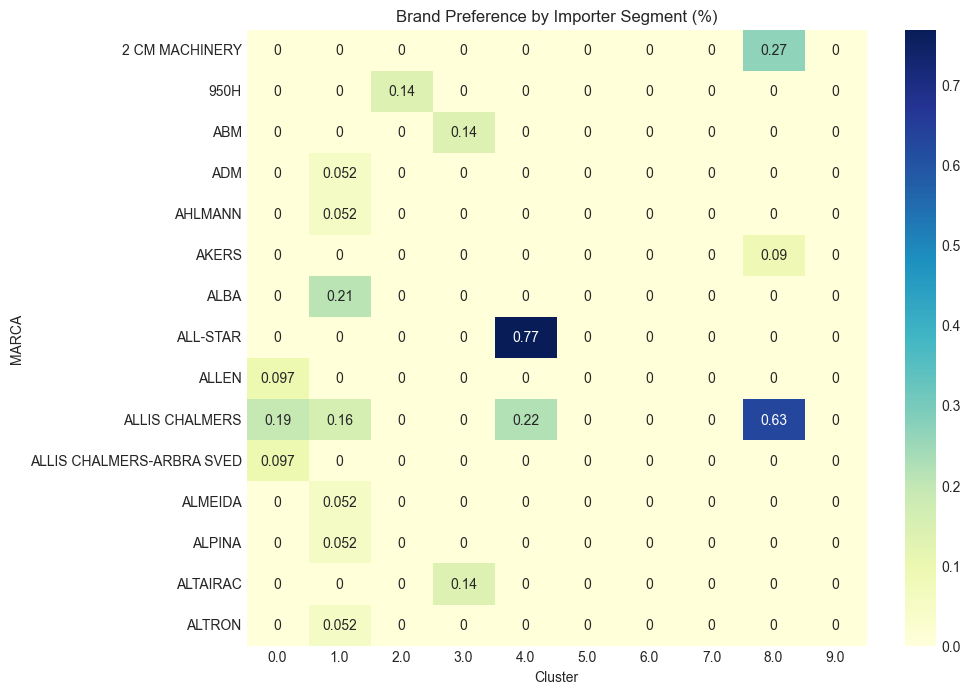

In [88]:
# First, ensure 'Cluster' column is in df_iron by mapping it from segmentation_data
# segmentation_data has 'RUC IMPORTADOR' as index and 'Cluster' column
df_iron['Cluster'] = df_iron['RUC IMPORTADOR'].map(segmentation_data['Cluster'])

# Create a Cross-Tabulation of Brand vs. Importer Cluster
brand_affinity = pd.crosstab(df_iron['MARCA'], df_iron['Cluster'], normalize='columns') * 100

plt.figure(figsize=(10, 8))
sns.heatmap(brand_affinity.head(15), annot=True, cmap='YlGnBu')
plt.title('Brand Preference by Importer Segment (%)')
plt.show()

In [89]:
#pip install mlxtend networkx

In [90]:
#pip install --upgrade pip

In [91]:
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Transform data into "Baskets" (Binary Matrix)
# Did Importer X ever buy Brand Y?
basket = (df_iron.groupby(['RUC IMPORTADOR', 'MARCA'])['US$ FOB']
          .count().unstack().reset_index().fillna(0)
          .set_index('RUC IMPORTADOR'))

# Convert counts to 0 or 1
def encode_units(x):
    return 1 if x >= 1 else 0

basket_sets = basket.map(encode_units)

# 2. Run Apriori
frequent_itemsets = apriori(basket_sets, min_support=0.03, use_colnames=True)

# 3. Generate Rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False).head(10))

                         antecedents                        consequents  \
4                 frozenset({VOLVO})  frozenset({UNKNOWN, CATERPILLAR})   
1  frozenset({UNKNOWN, CATERPILLAR})                 frozenset({VOLVO})   
3               frozenset({UNKNOWN})    frozenset({VOLVO, CATERPILLAR})   
2    frozenset({VOLVO, CATERPILLAR})               frozenset({UNKNOWN})   
0        frozenset({UNKNOWN, VOLVO})           frozenset({CATERPILLAR})   
5           frozenset({CATERPILLAR})        frozenset({UNKNOWN, VOLVO})   

   support  confidence  lift  
4     0.05        0.18  1.90  
1     0.05        0.48  1.90  
3     0.05        0.19  1.87  
2     0.05        0.45  1.87  
0     0.05        0.76  1.70  
5     0.05        0.10  1.70  


In [92]:
df_iron['BRAND_TYPE'] = df_iron['MARCA'] + "_" + df_iron['PRODUCTO']

basket_model = (df_iron.groupby(['RUC IMPORTADOR', 'BRAND_TYPE'])['US$ FOB']
                .count().unstack().reset_index().fillna(0)
                .set_index('RUC IMPORTADOR'))

basket_model_sets = basket_model.map(lambda x: 1 if x >= 1 else 0)

# Run Apriori on Brand_Type
frequent_itemsets_model = apriori(basket_model_sets, min_support=0.02, use_colnames=True)
rules_model = association_rules(frequent_itemsets_model, metric="lift", min_threshold=1.5)

print(rules_model[['antecedents', 'consequents', 'confidence', 'lift']].sort_values('lift', ascending=False))

                                          antecedents  \
17                frozenset({CATERPILLAR_EXCAVADORA})   
12  frozenset({UNKNOWN_UNKNOWN, VOLVO_CARGADOR FRO...   
16                frozenset({VOLVO_CARGADOR FRONTAL})   
13  frozenset({UNKNOWN_UNKNOWN, CATERPILLAR_EXCAVA...   
15                       frozenset({UNKNOWN_UNKNOWN})   
14  frozenset({VOLVO_CARGADOR FRONTAL, CATERPILLAR...   
10                frozenset({VOLVO_CARGADOR FRONTAL})   
11                      frozenset({VOLVO_EXCAVADORA})   
9                       frozenset({VOLVO_EXCAVADORA})   
8                        frozenset({UNKNOWN_UNKNOWN})   
5                 frozenset({CATERPILLAR_EXCAVADORA})   
4                       frozenset({VOLVO_EXCAVADORA})   
3                 frozenset({CATERPILLAR_EXCAVADORA})   
2                 frozenset({VOLVO_CARGADOR FRONTAL})   
1                 frozenset({CATERPILLAR_EXCAVADORA})   
0                        frozenset({UNKNOWN_UNKNOWN})   
7                 frozenset({VO

In [93]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 1. Create a cleaner Brand_Type column
df_iron['BRAND_TYPE'] = df_iron['MARCA'] + "_" + df_iron['PRODUCTO']

# 2. Filter for only the Top 30 most frequent combinations to reduce noise/complexity
top_combos = df_iron['BRAND_TYPE'].value_counts().nlargest(30).index
df_filtered = df_iron[df_iron['BRAND_TYPE'].isin(top_combos)]

# 3. Create the basket
basket_iron = (df_filtered.groupby(['RUC IMPORTADOR', 'BRAND_TYPE'])['US$ FOB']
               .count().unstack().reset_index().fillna(0)
               .set_index('RUC IMPORTADOR'))

# Binary encoding
basket_iron_sets = basket_iron.map(lambda x: 1 if x >= 1 else 0)

# 4. Use fpgrowth instead of apriori (Faster!)
# We set min_support to 0.03 (at least 3% of importers buy both)
frequent_itemsets_iron = fpgrowth(basket_iron_sets, min_support=0.03, use_colnames=True)

# 5. Generate Rules
rules_iron = association_rules(frequent_itemsets_iron, metric="lift", min_threshold=1.2)

# Sort and clean output to avoid JavaScript lag
rules_iron_clean = rules_iron[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False)
print(f"Discovered {len(rules_iron_clean)} associations.")
display(rules_iron_clean.head(15))

Discovered 18 associations.


,antecedents,consequents,support,confidence,lift
16,frozenset({VOLVO_EXCAVADORA}),"frozenset({VOLVO_CARGADOR FRONTAL, CATERPILLAR...",0.03,0.34,3.44
13,"frozenset({VOLVO_CARGADOR FRONTAL, CATERPILLAR...",frozenset({VOLVO_EXCAVADORA}),0.03,0.32,3.44
15,frozenset({VOLVO_CARGADOR FRONTAL}),"frozenset({VOLVO_EXCAVADORA, CATERPILLAR_EXCAV...",0.03,0.11,3.10
14,"frozenset({VOLVO_EXCAVADORA, CATERPILLAR_EXCAV...",frozenset({VOLVO_CARGADOR FRONTAL}),0.03,0.88,3.10
4,frozenset({CATERPILLAR_EXCAVADORA}),"frozenset({UNKNOWN_UNKNOWN, VOLVO_CARGADOR FRO...",0.06,0.18,2.45
1,"frozenset({UNKNOWN_UNKNOWN, VOLVO_CARGADOR FRO...",frozenset({CATERPILLAR_EXCAVADORA}),0.06,0.76,2.45
0,"frozenset({UNKNOWN_UNKNOWN, CATERPILLAR_EXCAVA...",frozenset({VOLVO_CARGADOR FRONTAL}),0.06,0.65,2.31
5,frozenset({VOLVO_CARGADOR FRONTAL}),"frozenset({UNKNOWN_UNKNOWN, CATERPILLAR_EXCAVA...",0.06,0.20,2.31
2,"frozenset({VOLVO_CARGADOR FRONTAL, CATERPILLAR...",frozenset({UNKNOWN_UNKNOWN}),0.06,0.56,2.20
3,frozenset({UNKNOWN_UNKNOWN}),"frozenset({VOLVO_CARGADOR FRONTAL, CATERPILLAR...",0.06,0.22,2.20


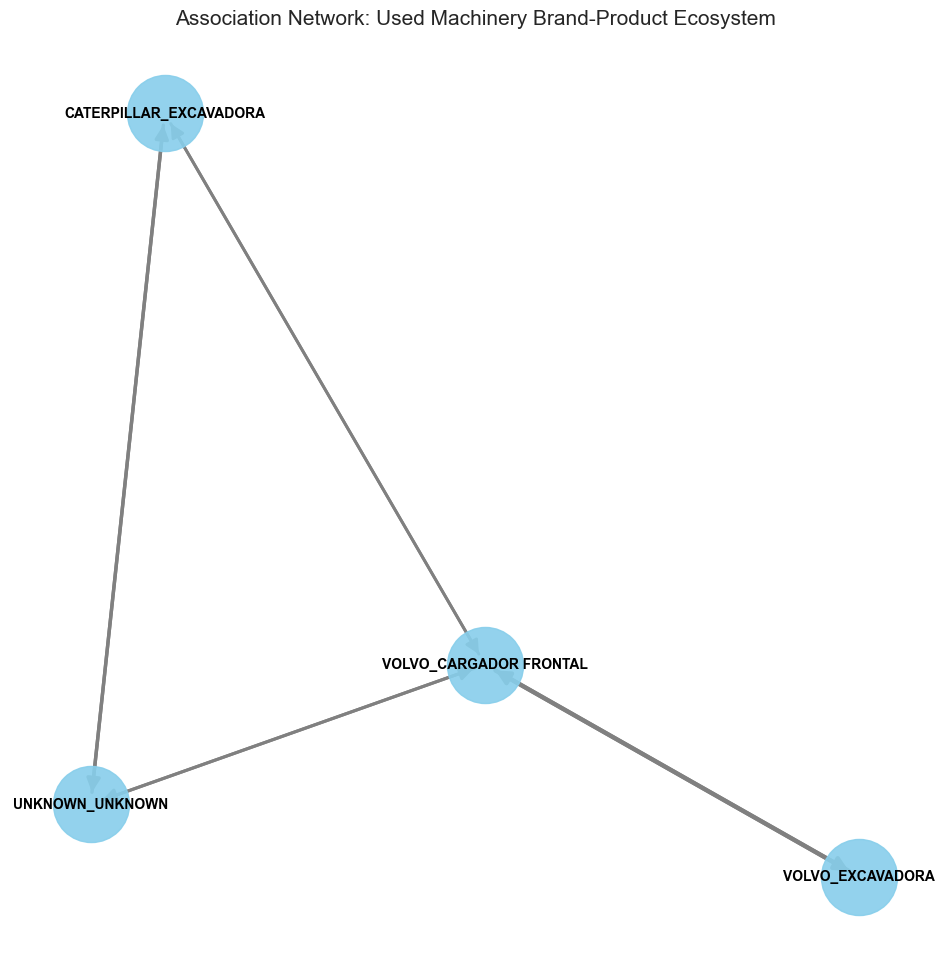

In [94]:
import networkx as nx

# Create the graph object
G = nx.DiGraph()

# Add edges based on your Top 10 rules
# We'll use 'Lift' to determine the thickness of the connection
for idx, row in rules_iron_clean.head(12).iterrows():
    ant = list(row['antecedents'])[0]
    con = list(row['consequents'])[0]
    G.add_edge(ant, con, weight=row['lift'])

# Positioning the nodes
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=1.5) # k adjusts the distance between nodes

# Draw the nodes and labels
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='skyblue', alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw the edges (thickness based on Lift)
weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', arrowsize=20)

plt.title('Association Network: Used Machinery Brand-Product Ecosystem', size=15)
plt.axis('off')
plt.show()

In [95]:
#checking if these rules change by cluster
# 1. Choose your Target Cluster (Let's say Cluster 1 - the Mid-Market)
target_cluster_rucs = segmentation_data[segmentation_data['Cluster'] == 1].index

# 2. Filter the basket for ONLY these RUCs
basket_target = basket_sets.loc[basket_sets.index.isin(target_cluster_rucs)]

# 3. Run FP-Growth again
freq_target = fpgrowth(basket_target, min_support=0.05, use_colnames=True)
rules_target = association_rules(freq_target, metric="lift", min_threshold=1.1)

print("--- Rules specifically for the Mid-Market Segment ---")
display(rules_target[['antecedents', 'consequents', 'confidence', 'lift']].sort_values('lift', ascending=False).head(10))

--- Rules specifically for the Mid-Market Segment ---


,antecedents,consequents,confidence,lift


In [96]:
# 1. Clean the 'Iron' dataset one last time (Surgical Approach)
df_clean_iron = df_iron[df_iron['BRAND_TYPE'].str.contains('UNKNOWN') == False].copy()

# 2. Sort by RUC and Year to create the timeline
df_timeline = df_clean_iron.sort_values(['RUC IMPORTADOR', 'ANO'])

# 3. Create the 'Sequence'
# We find the FIRST thing they ever bought vs the REST of their history
sequences = df_timeline.groupby('RUC IMPORTADOR')['BRAND_TYPE'].agg(list)

# Function to identify the 'Gateway' (First) and 'Expansion' (Subsequent) machines
def analyze_growth(seq):
    if len(seq) < 2: return None
    first = seq[0]
    subsequent = list(set(seq[1:])) # Unique machines bought after the first year
    return (first, subsequent)

growth_patterns = sequences.apply(analyze_growth).dropna()

# 4. Count the 'Gateway' Machines
gateways = pd.Series([x[0] for x in growth_patterns]).value_counts()

print("--- The 'Gateway' Machines (What they buy first) ---")
display(gateways.head(10))

--- The 'Gateway' Machines (What they buy first) ---


VOLVO_CARGADOR FRONTAL          110
CATERPILLAR_EXCAVADORA          100
CATERPILLAR_CARGADOR FRONTAL     41
CATERPILLAR_MOTONIVELADORA       25
VOLVO_EXCAVADORA                 21
CATERPILLAR_RETROEXCAVADORA      10
CATERPILLAR_MINICARGADOR         10
CATERPILLAR_MINI CARGADOR        10
HYUNDAI_EXCAVADORA               10
DOOSAN_EXCAVADORA                10
Name: count, dtype: int64

In [97]:
# seeing those who moved clusters
# 1. Compare activity between Early Period (2015-2019) and Late Period (2020-2024)
early_period = df_units[df_units['ANO'] <= 2019].groupby('RUC IMPORTADOR')['US$ FOB'].sum()
late_period = df_units[df_units['ANO'] >= 2020].groupby('RUC IMPORTADOR')['US$ FOB'].sum()

# 2. Find the "Risers" (Growth > 200%)
growth_df = pd.DataFrame({
    'Early_Spend': early_period,
    'Late_Spend': late_period
}).fillna(0)

growth_df['Growth_Rate'] = (growth_df['Late_Spend'] - growth_df['Early_Spend']) / growth_df['Early_Spend']
# Replacing infinity (if they started with 0) with a large number
growth_df.replace([np.inf, -np.inf], 10, inplace=True)

# 3. Filter for 'Success Stories'
# We want companies that were small but now spend over $500k in the late period
success_stories = growth_df[(growth_df['Early_Spend'] < 200000) & (growth_df['Late_Spend'] > 500000)]
success_stories['NAME'] = success_stories.index.map(name_map)

print("--- The 'Success Stories' (Rising Stars in Peru) ---")
display(success_stories[['NAME', 'Early_Spend', 'Late_Spend', 'Growth_Rate']].sort_values('Growth_Rate', ascending=False).head(10))

--- The 'Success Stories' (Rising Stars in Peru) ---


,NAME,Early_Spend,Late_Spend,Growth_Rate
RUC IMPORTADOR,,,,
20602250866,FC MACHINERY & CONSTRUCTION E.I.R.L.,"28,430.82","3,444,254.98",120.15
20603602481,CRS IMPORTACIONES SOCIEDAD ANONIMA CERRA,"38,833.00","4,199,346.65",107.14
20563930561,CORPORACION CORBACC SAC,"17,000.00","1,311,175.61",76.13
20602371442,CHINA GEZHOUBA GROUP COMPANY LIMITED SUC,"22,925.69","1,577,913.30",67.83
20602095771,ZAVALA INTERNATIONAL TRADING S.A.C.,"52,157.09","2,095,979.25",39.19
20555405864,CONTREMAR MAQUINARIAS Y CONSTRUCCIONES SOCIEDA...,"59,766.06","2,149,770.05",34.97
20558660237,LE MONDE MAQUINARIAS S.A.C.,"17,000.00","543,011.54",30.94
20600501373,SERVICIOS Y VENTAS RED CAR E.I.R.L.,"18,000.00","537,442.00",28.86
20602148093,MADERERA RV PERU E.I.R.L.,"18,613.00","553,031.00",28.71


In [98]:
# Identifying the Siblings of KARLA and KALICANTO
internal_sales_data = {
    '20517931536': 1636379, # KARLA EQUIPMENT
    '20490425668': 1157475, # KALICANTO
    '20602250866': 1149356, # FC MACHINERY
    '20519006422': 483564,  # TACKLLA
    '20606954442': 390337,  # ECA PERU
    '20601770815': 338473,  # DAMICON
    '10075145778': 36105,   # Perez Cahuana
    '20601066255': 36014,   # Transp. Const. D&Y
    '20606365196': 24027,   # LARF BUSINESS
    '20456340785': 24001,   # B&J CONTRATISTAS
    '20603430167': 22023,   # JYC INTERNATIONAL
    '20537454076': 17033,   # INVERSIONES RUMALDO
    '20609926440': 11800        # ANKARA PERU
}
client_ruc_list = list(internal_sales_data.keys())
target_clusters = [1] # Assuming Cluster 1 in your Dendrogram is the target
new_prospects = segmentation_data[
    (segmentation_data['HC_Cluster'].isin(target_clusters)) &
    (~segmentation_data.index.isin(client_ruc_list)) # Not currently a client
].sort_values('Total_Spend', ascending=False)

new_prospects['NAME'] = new_prospects.index.map(name_map)
print("--- Top 5 UNTAPPED Prospects (Lookalikes) ---")
display(new_prospects[['NAME', 'Total_Spend', 'Transaction_Count']].head(10))

--- Top 5 UNTAPPED Prospects (Lookalikes) ---


,NAME,Total_Spend,Transaction_Count
RUC IMPORTADOR,,,
20487799484,MATERIALES Y SERVICIOS GENERALES FABRI E.I.R.L.,"9,789,632.48",103
20100134706,SANDVIK DEL PERU S A,"6,392,561.98",15
20103913340,ORVISA SOCIEDAD ANONIMA,"6,009,140.83",60
20603189788,MAKITRADE PERU E.I.R.L.,"4,877,599.74",98
20564211908,KARMAX S.A.C.,"4,289,417.24",73
20603602481,CRS IMPORTACIONES SOCIEDAD ANONIMA CERRA,"4,238,179.65",72
20608277448,4B GLOBAL EQUIPMENT S.A.C.,"4,010,259.60",71
20546121250,STRACON GYM S.A.,"3,615,694.24",8
20100027021,UNIMAQ S.A.,"3,420,496.98",37


EXTRA: TRANSIT TIME ANALYSIS

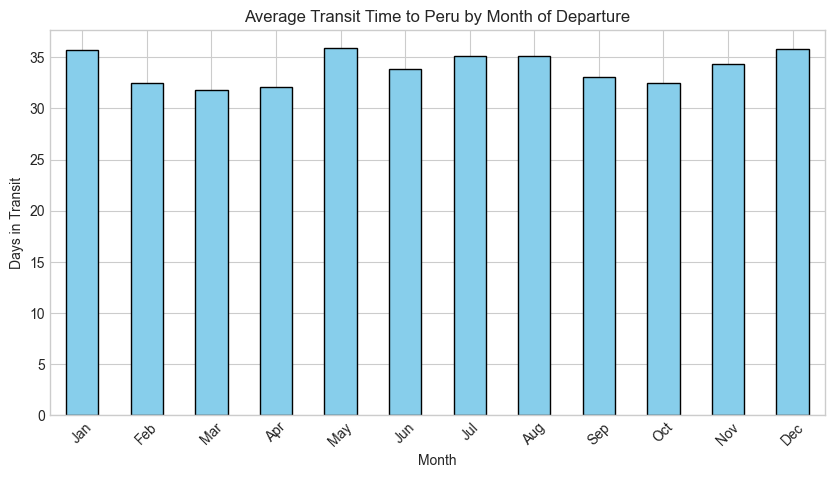

Global Average Transit Time: 34.0 days


In [99]:
# 1. Convert main date columns to datetime
# We use 'coerce' so that unparseable strings become NaT (Null)
df_units['FECHA_EMBARQUE'] = pd.to_datetime(df_units['FECHA DE EMBARQUE'], errors='coerce')
df_units['FECHA_LLEGADA'] = pd.to_datetime(df_units['FECHA DE LLEGADA'], errors='coerce')

# 2. Impute missing arrival dates
# Construct a date string from AÑO, MES, and DIA (defaulting to 1 if DIA is missing)
df_units['DIA_ALT'] = pd.to_numeric(df_units['DIA'], errors='coerce').fillna(1).astype(int)
df_units['FECHA_LLEGADA_ALT'] = pd.to_datetime(
    df_units['ANO'].astype(str) + '-' +
    df_units['MES'].astype(str) + '-' +
    df_units['DIA_ALT'].astype(str),
    errors='coerce'
)

# Fill gaps in arrival date
df_units['FECHA_LLEGADA_FINAL'] = df_units['FECHA_LLEGADA'].fillna(df_units['FECHA_LLEGADA_ALT'])

# 3. Calculate Transit Time (Days)
df_units['TRANSIT_DAYS'] = (df_units['FECHA_LLEGADA_FINAL'] - df_units['FECHA_EMBARQUE']).dt.days

# Filter for realistic transit times (e.g., 5 to 90 days) to remove errors
df_transit = df_units[(df_units['TRANSIT_DAYS'] > 5) & (df_units['TRANSIT_DAYS'] < 100)]

# 4. Seasonal Analysis: Average transit time by Month of Departure
seasonal_transit = df_transit.groupby(df_transit['FECHA_EMBARQUE'].dt.month)['TRANSIT_DAYS'].mean()

plt.figure(figsize=(10, 5))
seasonal_transit.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Transit Time to Peru by Month of Departure')
plt.xlabel('Month')
plt.ylabel('Days in Transit')
plt.xticks(range(0, 12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.show()

print(f"Global Average Transit Time: {df_transit['TRANSIT_DAYS'].mean():.1f} days")

In [100]:
# 1. Calculate spend by period
early_spend = df_units[df_units['ANO'] <= 2019].groupby('RUC IMPORTADOR')['US$ FOB'].sum()
late_spend = df_units[df_units['ANO'] >= 2020].groupby('RUC IMPORTADOR')['US$ FOB'].sum()

# 2. Compare and find the 'Risers'
success_df = pd.DataFrame({'Early': early_spend, 'Late': late_spend}).fillna(0)
success_df['Growth'] = success_df['Late'] - success_df['Early']

# Criteria: Spent < $100k Early, but > $1M Late
rising_stars = success_df[(success_df['Early'] < 100000) & (success_df['Late'] > 1000000)]
rising_stars['CLIENT_NAME'] = rising_stars.index.map(name_map)

print("--- TOP RISING STARS (Potential High-Growth Clients) ---")
display(rising_stars.sort_values('Late', ascending=False))

--- TOP RISING STARS (Potential High-Growth Clients) ---


,Early,Late,Growth,CLIENT_NAME
RUC IMPORTADOR,,,,
0,0.00,"29,056,890.91","29,056,890.91",Ley 29733 Protección de datos personales
20487799484,0.00,"9,789,632.48","9,789,632.48",MATERIALES Y SERVICIOS GENERALES FABRI E.I.R.L.
20606433469,0.00,"7,876,555.80","7,876,555.80",ECA BUSINESS E.I.R.L.
20103913340,0.00,"6,009,140.83","6,009,140.83",ORVISA SOCIEDAD ANONIMA
20564211908,0.00,"4,289,417.24","4,289,417.24",KARMAX S.A.C.
20603602481,"38,833.00","4,199,346.65","4,160,513.65",CRS IMPORTACIONES SOCIEDAD ANONIMA CERRA
20608277448,0.00,"4,010,259.60","4,010,259.60",4B GLOBAL EQUIPMENT S.A.C.
20606365196,0.00,"3,830,031.78","3,830,031.78",LARF BUSINESS E.I.R.L.
20602250866,"28,430.82","3,444,254.98","3,415,824.16",FC MACHINERY & CONSTRUCTION E.I.R.L.


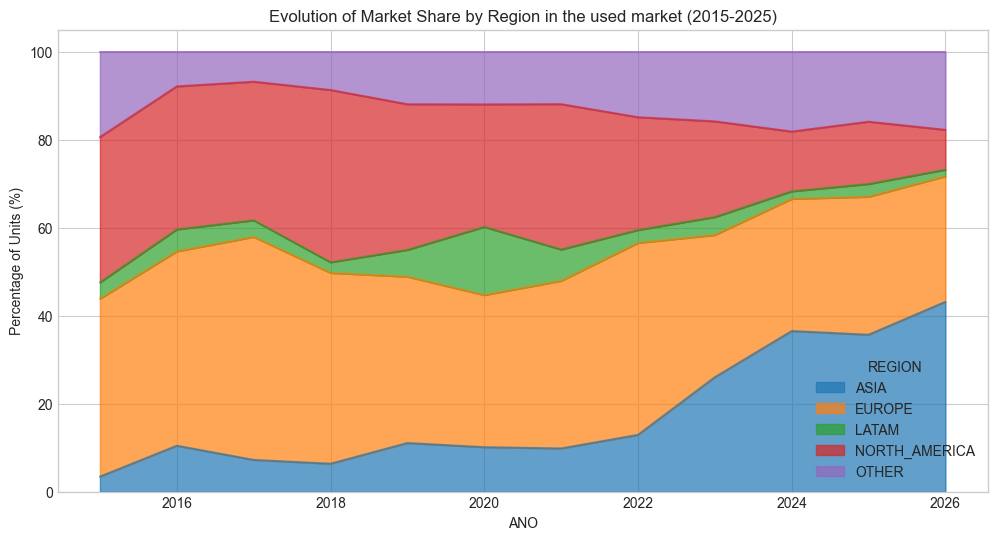

In [101]:
# 1. Define the Macro-Regions
region_map = {
    'SUECIA': 'EUROPE', 'BELGICA': 'EUROPE', 'HOLANDA': 'EUROPE', 'ALEMANIA': 'EUROPE',
    'ITALIA': 'EUROPE', 'REINO UNIDO': 'EUROPE', 'FRANCIA': 'EUROPE', 'ESPAÑA': 'EUROPE',
    'ESTADOS UNIDOS': 'NORTH_AMERICA', 'CANADA': 'NORTH_AMERICA',
    'CHINA': 'ASIA', 'COREA DEL SUR': 'ASIA', 'JAPON': 'ASIA', 'INDIA': 'ASIA',
    'BRASIL': 'LATAM', 'MEXICO': 'LATAM'
}

df_units['REGION'] = df_units['PAIS DE ORIGEN'].map(region_map).fillna('OTHER')

# 2. Regional Market Share Analysis
regional_share = df_units.groupby(['ANO', 'REGION']).size().unstack().fillna(0)
regional_share_pct = regional_share.div(regional_share.sum(axis=1), axis=0) * 100

# Plotting the "Invasion" of Asian brands vs Stability of EU
regional_share_pct.plot(kind='area', stacked=True, figsize=(12, 6), alpha=0.7)
plt.title('Evolution of Market Share by Region in the used market (2015-2025)')
plt.ylabel('Percentage of Units (%)')
plt.show()

In [102]:
# Apply region_map to df_units
df_units['REGION'] = df_units['PAIS DE ORIGEN'].map(region_map).fillna('OTHER')

# Build the RUC x REGION basket (binary: did this importer buy from this region?)
basket_region_sets = (
    df_units.groupby(['RUC IMPORTADOR', 'REGION'])
    .size()
    .unstack(fill_value=0)
    .clip(upper=1)          # binarise: 1 = bought from region, 0 = did not
    .astype(bool)           # mlxtend requires boolean dtype
)

# Regional market presence (share of importers active in each region)
regional_share_pct = basket_region_sets.mean() * 100

print(f"Basket shape: {basket_region_sets.shape}  ({basket_region_sets.shape[0]} importers x {basket_region_sets.shape[1]} regions)")
print("--- % of importers active in each region ---")
print(regional_share_pct.sort_values(ascending=False).round(1))


Basket shape: (1586, 5)  (1586 importers x 5 regions)
--- % of importers active in each region ---
REGION
ASIA            38.20
EUROPE          35.90
NORTH_AMERICA   33.10
OTHER           20.90
LATAM            8.90
dtype: float64


In [103]:
# Check the frequency of each region in your basket
print("--- Regional Market Presence ---")
print(basket_region_sets.mean().sort_values(ascending=False))

--- Regional Market Presence ---
REGION
ASIA            0.38
EUROPE          0.36
NORTH_AMERICA   0.33
OTHER           0.21
LATAM           0.09
dtype: float64


In [104]:
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Lower the threshold to find more 'hidden' connections
# min_support = 0.02 means at least 2% of importers must have this combo
freq_regions = apriori(basket_region_sets, min_support=0.02, use_colnames=True)

# 2. Check if we found ANY frequent itemsets with more than 1 region
freq_regions['length'] = freq_regions['itemsets'].apply(lambda x: len(x))
multi_itemsets = freq_regions[freq_regions['length'] > 1]

if multi_itemsets.empty:
    print("❌ Still no combinations found. Importers in your data tend to stick to ONLY one region.")
else:
    # 3. Generate Rules with a lower Lift threshold
    rules_regions = association_rules(freq_regions, metric="lift", min_threshold=0.8)

    print(f"✅ Success! Found {len(rules_regions)} regional associations.")
    display(rules_regions[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False))

✅ Success! Found 48 regional associations.


,antecedents,consequents,support,confidence,lift
43,"frozenset({OTHER, NORTH_AMERICA})","frozenset({EUROPE, ASIA})",0.02,0.36,4.43
38,"frozenset({EUROPE, ASIA})","frozenset({OTHER, NORTH_AMERICA})",0.02,0.27,4.43
42,"frozenset({ASIA, NORTH_AMERICA})","frozenset({EUROPE, OTHER})",0.02,0.38,4.31
39,"frozenset({EUROPE, OTHER})","frozenset({ASIA, NORTH_AMERICA})",0.02,0.24,4.31
41,"frozenset({ASIA, OTHER})","frozenset({EUROPE, NORTH_AMERICA})",0.02,0.41,4.06
40,"frozenset({EUROPE, NORTH_AMERICA})","frozenset({ASIA, OTHER})",0.02,0.21,4.06
35,"frozenset({EUROPE, ASIA, NORTH_AMERICA})",frozenset({OTHER}),0.02,0.62,2.96
46,frozenset({OTHER}),"frozenset({EUROPE, ASIA, NORTH_AMERICA})",0.02,0.10,2.96
37,"frozenset({ASIA, OTHER, NORTH_AMERICA})",frozenset({EUROPE}),0.02,0.85,2.37
44,frozenset({EUROPE}),"frozenset({ASIA, OTHER, NORTH_AMERICA})",0.02,0.06,2.37


In [105]:
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Lower support even more to find the 'Small' crossovers
# 0.01 = 1% of your total RUCs
freq_regions = apriori(basket_region_sets, min_support=0.01, use_colnames=True)

# 2. Focus specifically on the EUROPE-NORTH_AMERICA link
rules_regions = association_rules(freq_regions, metric="lift", min_threshold=0.5)

# 3. Filter for rules that involve EUROPE
europe_rules = rules_regions[
    rules_regions['antecedents'].apply(lambda x: 'EUROPE' in x) |
    rules_regions['consequents'].apply(lambda x: 'EUROPE' in x)
]

print(f"✅ Found {len(europe_rules)} rules involving Europe.")
display(europe_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False))

✅ Found 58 rules involving Europe.


,antecedents,consequents,support,confidence,lift
87,"frozenset({OTHER, NORTH_AMERICA})","frozenset({EUROPE, ASIA})",0.02,0.36,4.43
82,"frozenset({EUROPE, ASIA})","frozenset({OTHER, NORTH_AMERICA})",0.02,0.27,4.43
86,"frozenset({ASIA, NORTH_AMERICA})","frozenset({EUROPE, OTHER})",0.02,0.38,4.31
83,"frozenset({EUROPE, OTHER})","frozenset({ASIA, NORTH_AMERICA})",0.02,0.24,4.31
85,"frozenset({ASIA, OTHER})","frozenset({EUROPE, NORTH_AMERICA})",0.02,0.41,4.06
84,"frozenset({EUROPE, NORTH_AMERICA})","frozenset({ASIA, OTHER})",0.02,0.21,4.06
90,frozenset({OTHER}),"frozenset({EUROPE, ASIA, NORTH_AMERICA})",0.02,0.10,2.96
79,"frozenset({EUROPE, ASIA, NORTH_AMERICA})",frozenset({OTHER}),0.02,0.62,2.96
81,"frozenset({ASIA, OTHER, NORTH_AMERICA})",frozenset({EUROPE}),0.02,0.85,2.37
88,frozenset({EUROPE}),"frozenset({ASIA, OTHER, NORTH_AMERICA})",0.02,0.06,2.37


In [106]:
#companias que pueden comprarle a cptreucks
# Identify RUCs that have imported from BOTH regions
western_ruc_list = df_units[df_units['REGION'].isin(['EUROPE', 'NORTH_AMERICA'])].groupby('RUC IMPORTADOR')['REGION'].nunique()
western_rucs = western_ruc_list[western_ruc_list == 2].index

# Get their stats
western_tier_prospects = df_units[df_units['RUC IMPORTADOR'].isin(western_rucs)].groupby('RUC IMPORTADOR').agg({
    'US$ FOB': 'sum',
    'PRODUCTO': 'count'
}).rename(columns={'US$ FOB': 'Total_Investment', 'PRODUCTO': 'Unit_Count'}).sort_values('Total_Investment', ascending=False)

# Map names (Use your name_map dictionary)
western_tier_prospects['NAME'] = western_tier_prospects.index.map(name_map)

print("--- THE WESTERN-TIER ELITE ---")
display(western_tier_prospects.head(40))

--- THE WESTERN-TIER ELITE ---


,Total_Investment,Unit_Count,NAME
RUC IMPORTADOR,,,
20538234754,"51,342,940.90",837,MC MACHINERY & ELECTRONIC S.A.C
20100028698,"38,112,101.08",180,FERREYROS SOCIEDAD AN?NIMA
0,"29,056,890.91",561,Ley 29733 Protección de datos personales
20170072465,"23,375,503.01",4,SOCIEDAD MINERA CERRO VERDE S.A.A.
20517931536,"10,347,040.79",198,KARLA EQUIPMENT S.A.C.
20537984032,"10,076,569.89",207,DESERT LOGISTIC SERVICES S.A.C.
20606433469,"7,876,555.80",154,ECA BUSINESS E.I.R.L.
20601770815,"7,689,277.56",123,DAMICON BUSINESS S.A.C.
20100134706,"6,392,561.98",15,SANDVIK DEL PERU S A



--- TOP 10 WESTERN-TIER ELITE (Prospects already buying NA + EU Used Gear) ---


,Total_Used_FOB,Used_Units,NAME
RUC IMPORTADOR,,,
20538234754,"43,592,779.38",674,MC MACHINERY & ELECTRONIC S.A.C
0,"26,371,099.99",500,Ley 29733 Protección de datos personales
20517931536,"9,290,654.83",160,KARLA EQUIPMENT S.A.C.
20537984032,"8,687,082.13",165,DESERT LOGISTIC SERVICES S.A.C.
20601770815,"7,452,832.78",115,DAMICON BUSINESS S.A.C.
20606433469,"7,147,159.42",136,ECA BUSINESS E.I.R.L.
20546301312,"6,379,835.49",38,SICIMSPASUCURSALDELPERU
20100134706,"5,881,167.06",13,SANDVIK DEL PERU S A
20518118103,"5,819,485.61",144,TOTAL CAMIONETAS S.A.C.


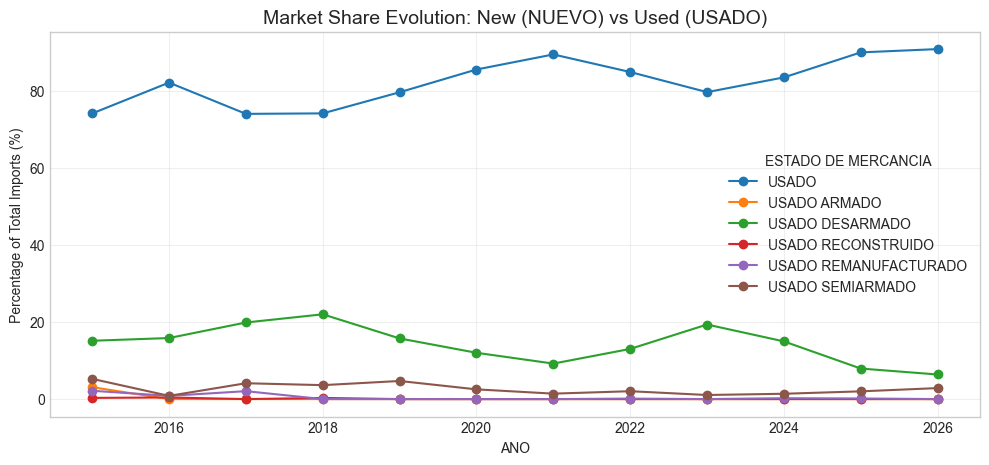

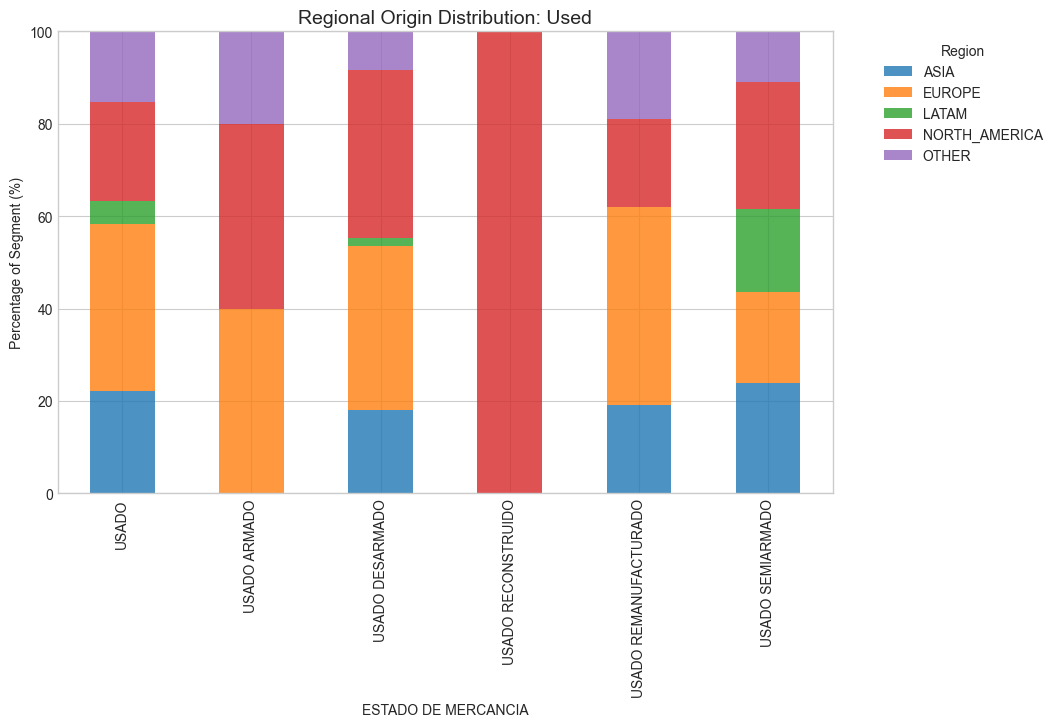


--- Top 10 Brands: NEW Market ---
Series([], Name: count, dtype: int64)

--- Top 10 Brands: USED Market ---
MARCA
CATERPILLAR    2863
VOLVO          2162
UNKNOWN         563
HYUNDAI         199
DOOSAN          149
Caterpillar     109
Volvo           108
KOMATSU          93
BOBCAT           63
JOHN DEERE       42
Name: count, dtype: int64


In [107]:
df_master = df_units.copy()

# 2. DEFINE MACRO-REGIONS
region_map = {
    'SUECIA': 'EUROPE', 'BELGICA': 'EUROPE', 'HOLANDA': 'EUROPE', 'ALEMANIA': 'EUROPE',
    'ITALIA': 'EUROPE', 'REINO UNIDO': 'EUROPE', 'FRANCIA': 'EUROPE', 'ESPAÑA': 'EUROPE',
    'ESTADOS UNIDOS': 'NORTH_AMERICA', 'CANADA': 'NORTH_AMERICA',
    'CHINA': 'ASIA', 'COREA DEL SUR': 'ASIA', 'JAPON': 'ASIA', 'INDIA': 'ASIA',
    'BRASIL': 'LATAM', 'MEXICO': 'LATAM'
}
df_master['REGION'] = df_master['PAIS DE ORIGEN'].map(region_map).fillna('OTHER')

# 3. IDENTIFY "WESTERN-TIER" ELITE (Targets in the USED Market)
# We filter for 'USADO' then find those buying from both EU and NA
df_used = df_master[df_master['ESTADO DE MERCANCIA'] == 'USADO']
western_ruc_list = df_used[df_used['REGION'].isin(['EUROPE', 'NORTH_AMERICA'])].groupby('RUC IMPORTADOR')['REGION'].nunique()
western_rucs = western_ruc_list[western_ruc_list == 2].index

western_elite = df_used[df_used['RUC IMPORTADOR'].isin(western_rucs)].groupby('RUC IMPORTADOR').agg({
    'US$ FOB': 'sum',
    'PRODUCTO': 'count'
}).rename(columns={'US$ FOB': 'Total_Used_FOB', 'PRODUCTO': 'Used_Units'}).sort_values('Total_Used_FOB', ascending=False)

# Mapping names (using your existing name_map dictionary)
western_elite['NAME'] = western_elite.index.map(name_map)

print("\n--- TOP 10 WESTERN-TIER ELITE (Prospects already buying NA + EU Used Gear) ---")
display(western_elite.head(10))

# 4. TREND ANALYSIS: NEW vs USED
market_trend = df_master.groupby(['ANO', 'ESTADO DE MERCANCIA']).size().unstack().fillna(0)
market_trend_pct = market_trend.div(market_trend.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 5))
market_trend_pct.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Market Share Evolution: New (NUEVO) vs Used (USADO)', fontsize=14)
plt.ylabel('Percentage of Total Imports (%)')
plt.grid(True, alpha=0.3)
plt.show()

# 5. REGIONAL ANALYSIS: DO WE TRUST ASIA FOR USED GEAR?
reg_comp = df_master.groupby(['ESTADO DE MERCANCIA', 'REGION']).size().unstack().fillna(0)
reg_comp_pct = reg_comp.div(reg_comp.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
reg_comp_pct.plot(kind='bar', stacked=True, ax=plt.gca(), alpha=0.8)
plt.title('Regional Origin Distribution: Used', fontsize=14)
plt.ylabel('Percentage of Segment (%)')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 6. BRAND DOMINANCE COMPARISON
print("\n--- Top 10 Brands: NEW Market ---")
print(df_master[df_master['ESTADO DE MERCANCIA'] == 'NUEVO']['MARCA'].value_counts().head(10))

print("\n--- Top 10 Brands: USED Market ---")
print(df_master[df_master['ESTADO DE MERCANCIA'] == 'USADO']['MARCA'].value_counts().head(10))

In [108]:
# Identify RUCs that import from both Europe and North America (Used Market)
df_used = df_master[df_master['ESTADO DE MERCANCIA'] == 'USADO']
regional_counts = df_used[df_used['REGION'].isin(['EUROPE', 'NORTH_AMERICA'])].groupby('RUC IMPORTADOR')['REGION'].nunique()
western_ruc_indices = regional_counts[regional_counts == 2].index

# Aggregate their stats
western_elite = df_used[df_used['RUC IMPORTADOR'].isin(western_ruc_indices)].groupby('RUC IMPORTADOR').agg({
    'US$ FOB': 'sum',
    'PRODUCTO': 'count'
}).rename(columns={'US$ FOB': 'Total_Used_FOB', 'PRODUCTO': 'Used_Units'}).sort_values('Total_Used_FOB', ascending=False)

# Assuming you have your name_map dictionary from the previous steps
western_elite['NAME'] = western_elite.index.map(name_map)

print("--- TOP 20 WESTERN-ELITE PROSPECTS ---")
display(western_elite.head(20))

--- TOP 20 WESTERN-ELITE PROSPECTS ---


,Total_Used_FOB,Used_Units,NAME
RUC IMPORTADOR,,,
20538234754,"43,592,779.38",674,MC MACHINERY & ELECTRONIC S.A.C
0,"26,371,099.99",500,Ley 29733 Protección de datos personales
20517931536,"9,290,654.83",160,KARLA EQUIPMENT S.A.C.
20537984032,"8,687,082.13",165,DESERT LOGISTIC SERVICES S.A.C.
20601770815,"7,452,832.78",115,DAMICON BUSINESS S.A.C.
20606433469,"7,147,159.42",136,ECA BUSINESS E.I.R.L.
20546301312,"6,379,835.49",38,SICIMSPASUCURSALDELPERU
20100134706,"5,881,167.06",13,SANDVIK DEL PERU S A
20518118103,"5,819,485.61",144,TOTAL CAMIONETAS S.A.C.


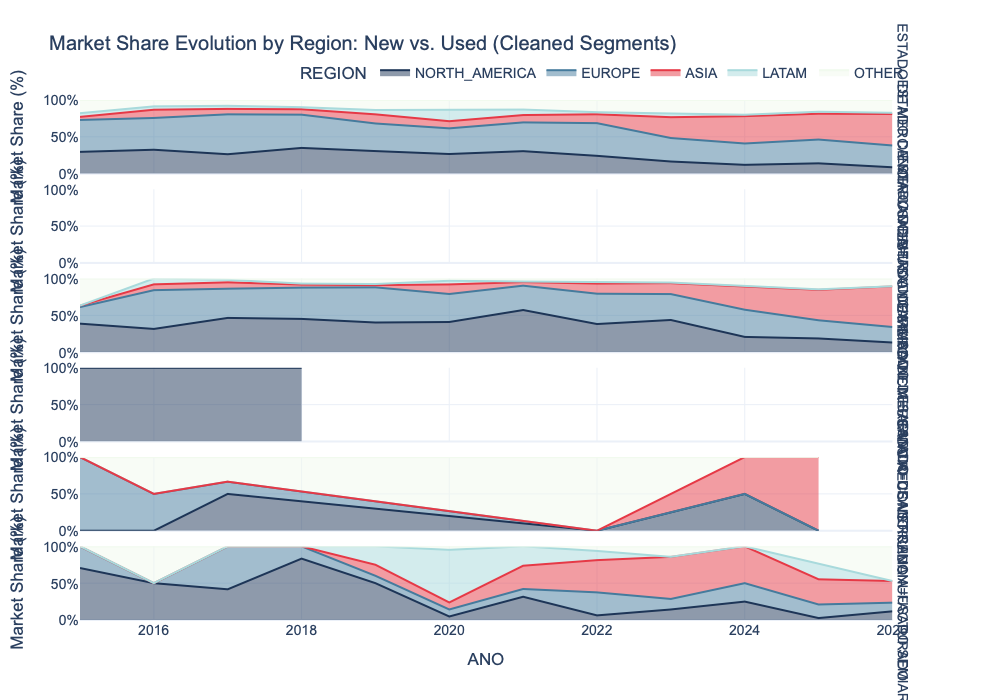

In [109]:
import plotly.express as px

# 1. Define the 'Noise' to filter out
noise_categories = ['OTROS', 'NUEVO SINIESTRADO', 'USADO SINIESTRADO', 'SINIESTRADO']

# 2. Filter the dataset to focus on the 'Clean' market
df_clean = df_master[~df_master['ESTADO DE MERCANCIA'].isin(noise_categories)].copy()

# 3. Calculate Regional Share per Year and State
df_shares = df_clean.groupby(['ANO', 'ESTADO DE MERCANCIA', 'REGION']).size().reset_index(name='Count')
df_shares['Percentage'] = df_shares.groupby(['ANO', 'ESTADO DE MERCANCIA'])['Count'].transform(lambda x: (x / x.sum()) * 100)

# 4. The "Our World in Data" Stacked Area Chart
fig = px.area(df_shares,
              x="ANO",
              y="Percentage",
              color="REGION",
              facet_row="ESTADO DE MERCANCIA", # NUEVO vs USADO
              category_orders={"ESTADO": ["NUEVO", "USADO"],
                               "REGION": ["NORTH_AMERICA", "EUROPE", "ASIA", "LATAM", "OTHER"]},
              color_discrete_map={
                  "NORTH_AMERICA": "#1D3557", # Deep Blue
                  "EUROPE": "#457B9D",        # Steel Blue
                  "ASIA": "#E63946",          # Vivid Red (The Invasion)
                  "LATAM": "#A8DADC",         # Light Blue
                  "OTHER": "#F1FAEE"          # Off-white
              },
              title="Market Share Evolution by Region: New vs. Used (Cleaned Segments)",
              labels={"Percentage": "Market Share (%)", "AÑO": "Year"},
              template="plotly_white")

fig.update_layout(
    height=700,
    font=dict(family="Arial", size=14),
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.update_yaxes(range=[0, 100], ticksuffix="%")
fig.show()

In [110]:
# Identify RUCs that import BOTH Europe and NA in the Clean Used market
df_used_clean = df_clean[df_clean['ESTADO DE MERCANCIA'] == 'USADO']
ruc_regional_count = df_used_clean[df_used_clean['REGION'].isin(['EUROPE', 'NORTH_AMERICA'])].groupby('RUC IMPORTADOR')['REGION'].nunique()
target_rucs = ruc_regional_count[ruc_regional_count == 2].index

# Rank them by total investment
prospects = df_used_clean[df_used_clean['RUC IMPORTADOR'].isin(target_rucs)].groupby('RUC IMPORTADOR').agg({
    'US$ FOB': 'sum',
    'PRODUCTO': 'count'
}).rename(columns={'US$ FOB': 'Total_Used_FOB', 'PRODUCTO': 'Unit_Count'}).sort_values('Total_Used_FOB', ascending=False)

# Map names (Assuming you have name_map)
prospects['COMPANY_NAME'] = prospects.index.map(name_map)

print("--- THE PLATINUM PROSPECTS (Target for CPtrucks) ---")
display(prospects.head(20))

--- THE PLATINUM PROSPECTS (Target for CPtrucks) ---


,Total_Used_FOB,Unit_Count,COMPANY_NAME
RUC IMPORTADOR,,,
20538234754,"43,592,779.38",674,MC MACHINERY & ELECTRONIC S.A.C
0,"26,371,099.99",500,Ley 29733 Protección de datos personales
20517931536,"9,290,654.83",160,KARLA EQUIPMENT S.A.C.
20537984032,"8,687,082.13",165,DESERT LOGISTIC SERVICES S.A.C.
20601770815,"7,452,832.78",115,DAMICON BUSINESS S.A.C.
20606433469,"7,147,159.42",136,ECA BUSINESS E.I.R.L.
20546301312,"6,379,835.49",38,SICIMSPASUCURSALDELPERU
20100134706,"5,881,167.06",13,SANDVIK DEL PERU S A
20518118103,"5,819,485.61",144,TOTAL CAMIONETAS S.A.C.


In [111]:
# 1. Filter for Companies only (In Peru, Company RUCs start with '20')
df_companies = df_clean[df_clean['RUC IMPORTADOR'].astype(str).str.startswith('20')].copy()

# 2. Identify the Western-Tier Elite within the Corporate Segment
# (Buying from both North America and Europe)
df_used_corp = df_companies[df_companies['ESTADO DE MERCANCIA'] == 'USADO']
corp_regional_count = df_used_corp[df_used_corp['REGION'].isin(['EUROPE', 'NORTH_AMERICA'])].groupby('RUC IMPORTADOR')['REGION'].nunique()
target_corp_rucs = corp_regional_count[corp_regional_count == 2].index

# 3. Create the Final Corporate Hit List
corporate_leads = df_used_corp[df_used_corp['RUC IMPORTADOR'].isin(target_corp_rucs)].groupby('RUC IMPORTADOR').agg({
    'US$ FOB': 'sum',
    'PRODUCTO': 'count'
}).rename(columns={'US$ FOB': 'Total_Used_FOB', 'PRODUCTO': 'Unit_Count'}).sort_values('Total_Used_FOB', ascending=False)

# Map names (ignore 'Ley de proteccion' here)
corporate_leads['COMPANY_NAME'] = corporate_leads.index.map(name_map)

print("--- TOP 20 CORPORATE TARGETS (RUC 20 only) ---")
display(corporate_leads.head(20))

--- TOP 20 CORPORATE TARGETS (RUC 20 only) ---


,Total_Used_FOB,Unit_Count,COMPANY_NAME
RUC IMPORTADOR,,,
20538234754,"43,592,779.38",674,MC MACHINERY & ELECTRONIC S.A.C
20517931536,"9,290,654.83",160,KARLA EQUIPMENT S.A.C.
20537984032,"8,687,082.13",165,DESERT LOGISTIC SERVICES S.A.C.
20601770815,"7,452,832.78",115,DAMICON BUSINESS S.A.C.
20606433469,"7,147,159.42",136,ECA BUSINESS E.I.R.L.
20546301312,"6,379,835.49",38,SICIMSPASUCURSALDELPERU
20100134706,"5,881,167.06",13,SANDVIK DEL PERU S A
20518118103,"5,819,485.61",144,TOTAL CAMIONETAS S.A.C.
20490425668,"5,405,085.36",82,KALICANTO PERU EIRL.


In [112]:
# 1. Clean and Filter
df_clean = df_master[
    (df_master['ESTADO DE MERCANCIA'] == 'USADO') &
    (df_master['RUC IMPORTADOR'].astype(str).str.startswith('20'))
].copy()

# 2. Aggregate
ruc_region_stats = df_clean.groupby(['RUC IMPORTADOR', 'REGION']).agg({
    'US$ FOB': 'sum',
    'PRODUCTO': 'count'
}).unstack(fill_value=0)

# 3. Flatten columns safely
ruc_region_stats.columns = [f"{col[1]}_{col[0]}" for col in ruc_region_stats.columns]

# --- ROBUSTNESS FIX ---
# We ensure the columns we need exist, even if they are all zeros
required_cols = ['EUROPE_count', 'NORTH_AMERICA_count', 'EUROPE_US$ FOB', 'NORTH_AMERICA_US$ FOB']
for col in required_cols:
    if col not in ruc_region_stats.columns:
        ruc_region_stats[col] = 0

# 4. Apply the 'Blue Ocean' Filter:
# ZERO Europe AND at least one North America
blue_ocean_filter = (ruc_region_stats['EUROPE_count'] < 10000000) & (ruc_region_stats['NORTH_AMERICA_count'] > 0)
blue_oceans = ruc_region_stats[blue_ocean_filter].copy()

# 5. Get Company Names and Top Brands
# We merge back with master to get descriptive info
names = df_clean.groupby('RUC IMPORTADOR')['IMPORTADOR'].first()
brands = df_clean.groupby('RUC IMPORTADOR')['MARCA'].agg(lambda x: x.mode()[0] if not x.mode().empty else "Various")

blue_oceans['COMPANY_NAME'] = blue_oceans.index.map(names)
blue_oceans['TOP_BRAND'] = blue_oceans.index.map(brands)

# 6. Final Sort and Display
blue_oceans = blue_oceans.sort_values('NORTH_AMERICA_US$ FOB', ascending=False)

print(f"✅ Success! Identified {len(blue_oceans)} Corporate Blue Oceans.")
display(blue_oceans[['COMPANY_NAME', 'NORTH_AMERICA_US$ FOB', 'NORTH_AMERICA_count', 'TOP_BRAND']].head(20))

# Export for your thesis appendix
blue_oceans.to_csv('BLUE_OCEAN_PROSPECTS_USA_LOYALISTS.csv')

✅ Success! Identified 0 Corporate Blue Oceans.


,COMPANY_NAME,NORTH_AMERICA_US$ FOB,NORTH_AMERICA_count,TOP_BRAND
RUC IMPORTADOR,,,,


In [113]:
# 1. Aggregate total spend and regional share per RUC
ruc_whale_stats = df_clean.groupby('RUC IMPORTADOR').agg({
    'US$ FOB': 'sum',
    'PRODUCTO': 'count'
}).rename(columns={'US$ FOB': 'Total_Market_Spend', 'PRODUCTO': 'Total_Units'})

# 2. Get the specific Spend per Region
region_spend = df_clean.groupby(['RUC IMPORTADOR', 'REGION'])['US$ FOB'].sum().unstack(fill_value=0)

# 3. Merge and Calculate Shares
whales = ruc_whale_stats.join(region_spend)
whales['EU_Share_Pct'] = (whales['EUROPE'] / whales['Total_Market_Spend']) * 100
whales['NA_Share_Pct'] = (whales['NORTH_AMERICA'] / whales['Total_Market_Spend']) * 100

# 4. DEFINE THE "TARGET WHALES":
# - Total Spend > $1,000,000
# - Europe Share < 10% (They are ignoring Europe)
# - North America Share > 50% (They are US-Loyalists)
target_whales = whales[
    (whales['Total_Market_Spend'] > 1000000) &
    (whales['EU_Share_Pct'] < 10) &
    (whales['NA_Share_Pct'] > 50)
].copy()

# 5. Add Names (Filter out protected data)
target_whales['COMPANY_NAME'] = target_whales.index.map(name_map)
identifiable_whales = target_whales[
    (target_whales['COMPANY_NAME'].notna()) &
    (~target_whales['COMPANY_NAME'].str.contains('PROTECCION|PERSONALES', case=False, na=False))
].sort_values('Total_Market_Spend', ascending=False)

print(f"✅ Found {len(identifiable_whales)} Target Whales with low European engagement.")
display(identifiable_whales[['COMPANY_NAME', 'Total_Market_Spend', 'EU_Share_Pct', 'NA_Share_Pct']].head(20))

✅ Found 5 Target Whales with low European engagement.


,COMPANY_NAME,Total_Market_Spend,EU_Share_Pct,NA_Share_Pct
RUC IMPORTADOR,,,,
20254813720,CHAVIN DE HUANTAR E.I.R.L,"2,692,125.58",2.72,86.84
20100047218,BANCO DE CREDITO DEL PERU,"1,898,722.90",0.00,94.84
20602371442,CHINA GEZHOUBA GROUP COMPANY LIMITED SUC,"1,600,838.99",0.00,54.75
20470234599,A K DRILLING INTERNATIONAL S.A.,"1,166,673.12",0.00,64.00
20563254921,IMPORTACIONES DE MAQUINARIAS YARLEQUE S.A.C.,"1,021,360.65",0.00,96.67


In [114]:
# 1. Start with Clean Corporate Used Data
df_clean = df_master[
    (df_master['ESTADO DE MERCANCIA'] == 'USADO') &
    (df_master['RUC IMPORTADOR'].astype(str).str.startswith('20'))
].copy()

# 2. Calculate Total Spend and Regional Spend per RUC
ruc_totals = df_clean.groupby('RUC IMPORTADOR')['US$ FOB'].sum().rename('Total_FOB')
region_spend = df_clean.groupby(['RUC IMPORTADOR', 'REGION'])['US$ FOB'].sum().unstack(fill_value=0)

# 3. Combine and Calculate Shares
whales = region_spend.join(ruc_totals)
whales['EU_Share_Pct'] = (whales['EUROPE'] / whales['Total_FOB']) * 100
whales['NA_Share_Pct'] = (whales['NORTH_AMERICA'] / whales['Total_FOB']) * 100

# 4. THE WHALE FILTER:
# - Spent > $1,000,000 total in the used market
# - Europe Share < 10% (They are ignoring Europe)
# - North America Share > 50% (They are US-Loyalists)
target_whales = whales[
    (whales['Total_FOB'] > 1000000) &
    (whales['EU_Share_Pct'] < 10) &
    (whales['NA_Share_Pct'] > 50)
].copy()

# 5. Add Names and Filter out "Noise" (Banks and Dealers)
target_whales['COMPANY_NAME'] = target_whales.index.map(name_map)

# Exclusion list for non-target industries
noise_keywords = 'BANCO|BANK|LEASING|CREDITO|FINANCI|PROTECCION|PERSONALES'
identifiable_whales = target_whales[
    (target_whales['COMPANY_NAME'].notna()) &
    (~target_whales['COMPANY_NAME'].str.contains(noise_keywords, case=False, na=False))
].sort_values('Total_FOB', ascending=False)

print(f"✅ Found {len(identifiable_whales)} Target Whales with low European engagement.")
display(identifiable_whales[['COMPANY_NAME', 'Total_FOB', 'EU_Share_Pct', 'NA_Share_Pct']].head(20))

✅ Found 4 Target Whales with low European engagement.


,COMPANY_NAME,Total_FOB,EU_Share_Pct,NA_Share_Pct
RUC IMPORTADOR,,,,
20254813720,CHAVIN DE HUANTAR E.I.R.L,"2,692,125.58",2.72,86.84
20602371442,CHINA GEZHOUBA GROUP COMPANY LIMITED SUC,"1,600,838.99",0.00,54.75
20470234599,A K DRILLING INTERNATIONAL S.A.,"1,166,673.12",0.00,64.00
20563254921,IMPORTACIONES DE MAQUINARIAS YARLEQUE S.A.C.,"1,021,360.65",0.00,96.67


In [115]:
# 1. Start with Corporate Used Data
df_used_corp = df_clean[
    (df_clean['ESTADO DE MERCANCIA'] == 'USADO') &
    (df_clean['RUC IMPORTADOR'].astype(str).str.startswith('20'))
].copy()

# 2. Get Spend by Region for every RUC
whale_stats = df_used_corp.groupby(['RUC IMPORTADOR', 'REGION'])['US$ FOB'].sum().unstack(fill_value=0)

# 3. Add Total Spend
whale_stats['Total_Used_FOB'] = whale_stats.sum(axis=1)

# 4. Calculate the 'Bias'
whale_stats['NA_Bias_Pct'] = (whale_stats['NORTH_AMERICA'] / whale_stats['Total_Used_FOB']) * 100
whale_stats['EU_Presence_Pct'] = (whale_stats['EUROPE'] / whale_stats['Total_Used_FOB']) * 100

# 5. THE "GREY OCEAN" FILTER:
# - Spend > $500,000 (Let's lower the bar slightly to see the 'Mid-Whales')
# - North America > 60% of their business
# - Europe < 15% (They know EU exists, but they don't buy much there)
grey_whales = whale_stats[
    (whale_stats['Total_Used_FOB'] > 500000) &
    (whale_stats['NA_Bias_Pct'] > 60) &
    (whale_stats['EU_Presence_Pct'] < 15)
].copy()

# 6. Add Names and Filter out the "Voldemorts" (Protected Data)
grey_whales['COMPANY_NAME'] = grey_whales.index.map(name_map)
noise_filter = 'BANCO|BANK|LEASING|CREDITO|FINANCI|PROTECCION|PERSONALES|SEGURIDAD'

final_whales = grey_whales[
    (grey_whales['COMPANY_NAME'].notna()) &
    (~grey_whales['COMPANY_NAME'].str.contains(noise_filter, case=False, na=False))
].sort_values('Total_Used_FOB', ascending=False)

print(f"✅ Found {len(final_whales)} 'Grey Ocean' Whales (US-Biased).")
display(final_whales[['COMPANY_NAME', 'Total_Used_FOB', 'NA_Bias_Pct', 'EU_Presence_Pct']].head(25))

✅ Found 7 'Grey Ocean' Whales (US-Biased).


REGION,COMPANY_NAME,Total_Used_FOB,NA_Bias_Pct,EU_Presence_Pct
RUC IMPORTADOR,,,,
20254813720,CHAVIN DE HUANTAR E.I.R.L,"2,692,125.58",86.84,2.72
20470234599,A K DRILLING INTERNATIONAL S.A.,"1,166,673.12",64.00,0.00
20563254921,IMPORTACIONES DE MAQUINARIAS YARLEQUE S.A.C.,"1,021,360.65",96.67,0.00
20314028164,CORPORACION ASFALTOS Y PAVIMENTOS CASTILLO S.A.C.,"948,139.34",76.96,11.60
20553870870,CONETEC PERU S.A.C.,"745,863.60",68.99,0.00
20228636658,EMPRESA DE SERVICIOS AGRICOLAS E INDUS TRIALES...,"593,636.60",89.43,3.75
20490482033,INKAS TRACTOR EMPRESA INDIVIDUAL DE RESPONSABI...,"591,690.00",74.95,10.86


In [116]:
# 1. Surgical Noise Filter
# We exclude protected data, individuals, and financial institutions
noise_mask = 'PROTECCION|PERSONALES|BANCO|BANK|LEASING|CREDITO|FINANCI|CONTINENTAL|SCOTIA'
df_corp_clean = df_clean[
    (df_clean['RUC IMPORTADOR'].astype(str).str.startswith('20')) &
    (~df_clean['IMPORTADOR'].str.contains(noise_mask, case=False, na=False))
].copy()

# 2. Re-run Grey Ocean Logic
whale_stats = df_corp_clean.groupby(['RUC IMPORTADOR', 'REGION'])['US$ FOB'].sum().unstack(fill_value=0)
whale_stats['Total_FOB'] = whale_stats.sum(axis=1)

# Ensure columns exist
for c in ['NORTH_AMERICA', 'EUROPE']:
    if c not in whale_stats.columns: whale_stats[c] = 0

whale_stats['NA_Bias'] = (whale_stats['NORTH_AMERICA'] / whale_stats['Total_FOB']) * 100
whale_stats['EU_Share'] = (whale_stats['EUROPE'] / whale_stats['Total_FOB']) * 100

# 3. The "Actionable Dolphin" Filter
# - Spend > $300,000 (The "Sweet Spot" for B2B Sales)
# - NA Bias > 70%
# - EU Share < 10%
dolphins = whale_stats[
    (whale_stats['Total_FOB'] > 300000) &
    (whale_stats['NA_Bias'] > 70) &
    (whale_stats['EU_Share'] < 10)
].copy()

# 4. Map Names and Top Brands
dolphins['COMPANY_NAME'] = dolphins.index.map(name_map)
brands = df_corp_clean.groupby('RUC IMPORTADOR')['MARCA'].agg(lambda x: x.mode()[0] if not x.mode().empty else "Mix")
dolphins['PRIMARY_BRAND'] = dolphins.index.map(brands)

print(f"✅ Found {len(dolphins)} Identifiable Corporate 'Dolphins' (Actionable Leads).")
display(dolphins[['COMPANY_NAME', 'Total_FOB', 'NA_Bias', 'PRIMARY_BRAND']].sort_values('Total_FOB', ascending=False).head(30))

✅ Found 7 Identifiable Corporate 'Dolphins' (Actionable Leads).


REGION,COMPANY_NAME,Total_FOB,NA_Bias,PRIMARY_BRAND
RUC IMPORTADOR,,,,
20254813720,CHAVIN DE HUANTAR E.I.R.L,"2,692,125.58",86.84,CATERPILLAR
20563254921,IMPORTACIONES DE MAQUINARIAS YARLEQUE S.A.C.,"1,021,360.65",96.67,CATERPILLAR
20228636658,EMPRESA DE SERVICIOS AGRICOLAS E INDUS TRIALES...,"593,636.60",89.43,VOLVO
20549011196,P.A. PERU S.A.C.,"451,716.33",100.00,VERMEER
20393625890,JVJ SERVICE ORIENTE S.A.C.,"440,000.00",100.00,MANTIS
20311785509,TRALEX S.C.R LTDA.,"377,310.87",93.12,CATERPILLAR
20556705365,INVERSIONES RUMALDO E.I.R.L.,"322,800.00",100.00,GOMACO


### CPTrucks Share-of-Wallet Analysis

In [117]:
# 1. Flag transactions from your company (CPtrucks)
# Note: Check if the exporter name in your CSV is 'CP TRUCK', 'CPTRUCKS', etc.
df_used_market['is_cptrucks'] = df_used_market['PROBABLE EMBARCADOR'].str.contains('CP TRUCK', na=False, case=False)

# 2. Calculate total spend vs spend with you
sow_df = df_used_market.groupby('RUC IMPORTADOR').agg(
    Total_Imported_FOB=('US$ FOB', 'sum'),
    CPtrucks_FOB=('US$ FOB', lambda x: x[df_used_market.loc[x.index, 'is_cptrucks']].sum())
)

# 3. Final SoW percentage
sow_df['Share_of_Wallet'] = (sow_df['CPtrucks_FOB'] / sow_df['Total_Imported_FOB']) * 100

In [118]:
### SOW

# 1. Define your internal sales data (from your Belgian invoices)
# Mapping RUC to the Sales Sum from your screenshot
internal_sales_data = {
    '20517931536': 1636379, # KARLA EQUIPMENT
    '20490425668': 1157475, # KALICANTO
    '20602250866': 1149356, # FC MACHINERY
    '20519006422': 483564,  # TACKLLA
    '20606954442': 390337,  # ECA PERU
    '20601770815': 338473,  # DAMICON
    '10075145778': 36105,   # Perez Cahuana
    '20601066255': 36014,   # Transp. Const. D&Y
    '20606365196': 24027,   # LARF BUSINESS
    '20456340785': 24001,   # B&J CONTRATISTAS
    '20603430167': 22023,   # JYC INTERNATIONAL
    '20537454076': 17033,   # INVERSIONES RUMALDO
    '20609926440': 11800        # ANKARA PERU
}

# 2. Extract Total Market Activity for these specific clients
# We use the clean used-machinery dataset (df_units)
client_ruc_list = list(internal_sales_data.keys())

market_activity = df_units[df_units['RUC IMPORTADOR'].isin(client_ruc_list)].groupby('RUC IMPORTADOR').agg(
    Total_Imported_FOB=('US$ FOB', 'sum'),
    Transactions=('RUC IMPORTADOR', 'count'),
    Avg_Price_Per_Unit=('US$ FOB', 'mean'),
    Main_Origin=('PAIS DE ORIGEN', lambda x: x.mode()[0] if not x.mode().empty else "Unknown")
)

# 3. Combine Internal vs External
sow_results = market_activity.copy()
sow_results['Sales_From_CPTRUCKS'] = sow_results.index.map(internal_sales_data)

# Calculate the Share of Wallet (%)
sow_results['Share_of_Wallet'] = (sow_results['Sales_From_CPTRUCKS'] / sow_results['Total_Imported_FOB']) * 100

# Add Client Names for readability
sow_results['CLIENT_NAME'] = sow_results.index.map(name_map) # Using the name_map we created earlier

# 4. Final Table
sow_final = sow_results[['CLIENT_NAME', 'Sales_From_CPTRUCKS', 'Total_Imported_FOB', 'Share_of_Wallet', 'Transactions', 'Main_Origin']]
sow_final = sow_final.sort_values('Total_Imported_FOB', ascending=False)

pd.options.display.float_format = '{:,.2f}'.format
display(sow_final)

,CLIENT_NAME,Sales_From_CPTRUCKS,Total_Imported_FOB,Share_of_Wallet,Transactions,Main_Origin
RUC IMPORTADOR,,,,,,
20517931536,KARLA EQUIPMENT S.A.C.,1636379,"10,347,040.79",15.81,198,BELGICA
20601770815,DAMICON BUSINESS S.A.C.,338473,"7,689,277.56",4.40,123,SUECIA
20490425668,KALICANTO PERU EIRL.,1157475,"5,719,062.23",20.24,94,SUECIA
20606365196,LARF BUSINESS E.I.R.L.,24027,"3,830,031.78",0.63,55,ESTADOS UNIDOS
20602250866,FC MACHINERY & CONSTRUCTION E.I.R.L.,1149356,"3,472,685.80",33.10,71,FRANCIA
20603430167,JYC INTERNATIONAL BUSINESS S.A.C.,22023,"2,147,210.02",1.03,32,SUECIA
20519006422,TACKLLA PERU SAC,483564,"2,025,270.16",23.88,39,FRANCIA
20609926440,ANKARA PERU E.I.R.L,11800,"974,901.41",1.21,14,JAPON
20456340785,INVERSIONES Y NEGOCIOS B & J CONTRATISTAS GENE...,24001,"86,600.00",27.71,1,JAPON


In [ ]:
# ── Handoff: save MBA outputs for the time series notebook ─────────────────
import pickle, os

_handoff = {
    # Pass-throughs from clustering
    'df_units':          df_units,
    'df_used_market':    df_used_market,
    'name_map':          name_map,
    'segmentation_data': segmentation_data,
    # Built in MBA
    'success_stories':   success_stories,
    'sow_final':         sow_final,
}
_handoff_path = 'mba_handoff.pkl'
with open(_handoff_path, 'wb') as _f:
    pickle.dump(_handoff, _f)
print(f'Saved MBA handoff → {os.path.abspath(_handoff_path)}')
print(f'  success_stories rows : {len(success_stories)}')
print(f'  sow_final rows       : {len(sow_final)}')


Saved MBA handoff → /Users/fabriziocontreras/Desktop/KUL/Masters/Thesis/code/mba_handoff.pkl
  success_stories rows : 91
  sow_final rows       : 10
